In [1]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

In [3]:
# Task 1: Data Understanding

# Task 1: Data Understanding

In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
numerical = df.select_dtypes(include=['int64','float64']).columns
print(numerical)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [9]:
categorical = df.select_dtypes(include=['object']).columns
print(categorical)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


Target Variable:

Attrition

# Task 2: Data Preprocessing

In [11]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [12]:
df = df.drop(["EmployeeCount","EmployeeNumber","Over18","StandardHours"], axis=1)

In [13]:
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype=="object":
        df[column]=encoder.fit_transform(df[column])

In [14]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [15]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Task 3: Model Development

In [16]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [17]:
dt_pred = dt.predict(X_test)

In [18]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [19]:
rf_pred = rf.predict(X_test)

# Task 4: Model Evaluation

In [20]:
print("Decision Tree")

print("Accuracy:",accuracy_score(y_test,dt_pred))
print("Precision:",precision_score(y_test,dt_pred))
print("Recall:",recall_score(y_test,dt_pred))
print("F1:",f1_score(y_test,dt_pred))

Decision Tree
Accuracy: 0.7993197278911565
Precision: 0.23684210526315788
Recall: 0.23076923076923078
F1: 0.23376623376623376


In [21]:
print(confusion_matrix(y_test,dt_pred))

[[226  29]
 [ 30   9]]


In [22]:
print("Random Forest")

print("Accuracy:",accuracy_score(y_test,rf_pred))
print("Precision:",precision_score(y_test,rf_pred))
print("Recall:",recall_score(y_test,rf_pred))
print("F1:",f1_score(y_test,rf_pred))

Random Forest
Accuracy: 0.8809523809523809
Precision: 0.8333333333333334
Recall: 0.1282051282051282
F1: 0.2222222222222222


In [23]:
print(confusion_matrix(y_test,rf_pred))

[[254   1]
 [ 34   5]]


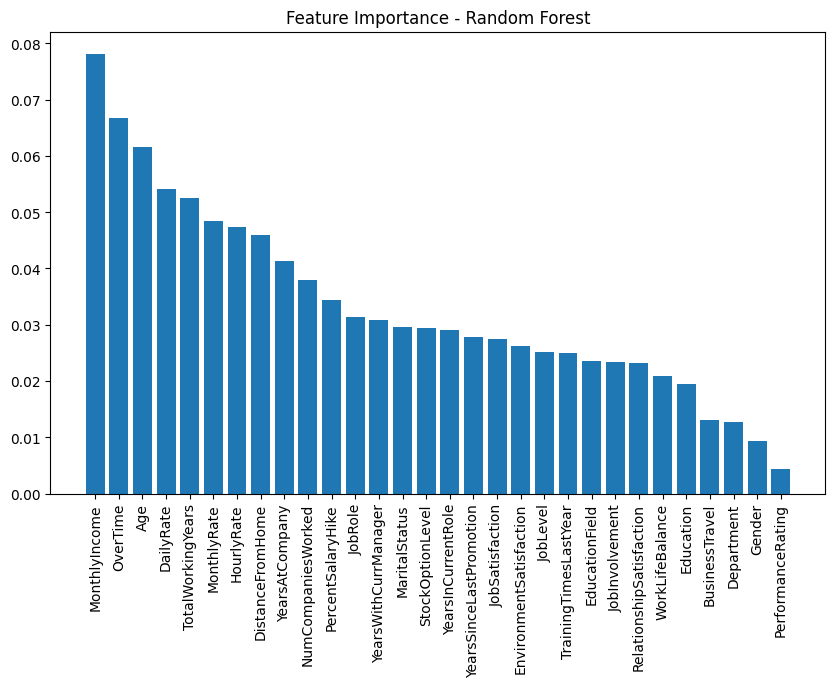

In [24]:
importance = rf.feature_importances_

features = X.columns

indices = np.argsort(importance)[::-1]

plt.figure(figsize=(10,6))

plt.bar(range(len(features)), importance[indices])

plt.xticks(range(len(features)), features[indices], rotation=90)

plt.title("Feature Importance - Random Forest")

plt.show()

# Observations

# Observations

### Observation 1
Random Forest achieved higher accuracy than the Decision Tree model.

### Observation 2
The Random Forest confusion matrix showed fewer misclassified employees than the Decision Tree.

### Observation 3
Random Forest uses multiple trees, making it more stable and reducing overfitting.

### Observation 4
Feature importance showed that variables such as MonthlyIncome, Age, TotalWorkingYears, and YearsAtCompany had a significant influence on employee attrition.

# Conclusion

# Conclusion

This project developed two machine learning models, Decision Tree and Random Forest, to predict employee attrition using the IBM HR Analytics dataset. The dataset was preprocessed by checking for missing values, removing unnecessary columns, encoding categorical variables, and splitting the data into training and testing sets. Both models were evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix. The Random Forest model performed better because it combines the predictions of multiple decision trees, reducing overfitting and improving generalization. Decision Trees are easy to understand and visualize but often overfit the training data, leading to lower performance on unseen data. Random Forest provides higher accuracy and robustness, although it requires more computational resources and is less interpretable than a single Decision Tree. Overall, Random Forest proved to be the more reliable model for predicting employee attrition and identifying important factors that influence employee turnover.